# Autores:

### Héctor Herraiz Díez, NIA: 100499734
### Javier Moyano San Bruno, NIA: 100495884
---

# Práctica 2: Clustering de semillas

## Paso 1: Comparación visual de escaladores con PCA

En este bloque se aplica Principal Component Analysis (PCA) a los datos de semillas usando tres escaladores distintos: `StandardScaler`, `MinMaxScaler` y `RobustScaler`. 

Se visualiza para cada escalador:
1. La varianza explicada por cada componente principal.
2. La representación de los datos en 2D según las dos primeras componentes.

Esto permitirá elegir el escalador más adecuado antes de aplicar técnicas de clustering.

In [472]:
# 📌 Librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Configuración
seed = 100495884  # NIA del estudiante
plt.style.use('ggplot')

In [473]:
# 📌 Cargar y preparar los datos
df = pd.read_csv('../data/semillas.csv')
X = df.drop(columns=['clase'])  

In [474]:
# 📌 Función para visualizar varianza explicada por PCA
def mostrar_varianza(X, scaler, nombre_scaler):
    pipe = Pipeline([
        ('scaler', scaler),
        ('pca', PCA())
    ])
    X_pca = pipe.fit_transform(X)
    pca = pipe.named_steps['pca']
    varianza_explicada = pca.explained_variance_ratio_
    varianza_acumulada = np.cumsum(varianza_explicada)

    # Gráfico de varianza
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, len(varianza_explicada) + 1), varianza_explicada, alpha=0.6, label='Varianza individual', color='darkgreen')
    plt.step(range(1, len(varianza_acumulada) + 1), varianza_acumulada, where='mid', label='Varianza acumulada', color='red')

    for i, (ev, cv) in enumerate(zip(varianza_explicada, varianza_acumulada)):
        plt.text(i + 1, ev + 0.01, f"{ev:.2%}", ha='center')
        plt.text(i + 1, cv + 0.01, f"{cv:.2%}", ha='center', color='red')

    plt.xlabel('Componentes Principales')
    plt.ylabel('Varianza Explicada')
    plt.title(f'Varianza explicada por PCA - {nombre_scaler}')
    plt.legend(loc='best')
    plt.ylim(0, 1.1)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()



In [475]:
# 📌 Función para visualizar proyección 2D de PCA Y mostrar varianza acumulada
def mostrar_pca_2d(X, scaler, nombre_scaler, seed):
    pipe = Pipeline([
        ('scaler', scaler),
        ('pca', PCA(n_components=2, random_state=seed))
    ])
    X_2d = pipe.fit_transform(X)
    pca_2d = pipe.named_steps['pca']
    var0 = pca_2d.explained_variance_ratio_[0]
    var1 = pca_2d.explained_variance_ratio_[1]
    total = var0 + var1

    # Gráfico
    plt.figure(figsize=(8, 6))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], s=40, c=df['clase'], cmap='viridis', alpha=0.8, edgecolor='k')
    plt.title(f'PCA 2D - {nombre_scaler}\n(Varianza: {var0:.2%} + {var1:.2%})')
    plt.xlabel(f'Componente 1 ({var0:.2%})')
    plt.ylabel(f'Componente 2 ({var1:.2%})')
    plt.grid(True)
    plt.show()

    # Imprimir varianza acumulada
    print(f"{nombre_scaler} → Varianza acumulada: {var0:.2%} + {var1:.2%} = {total:.2%}")


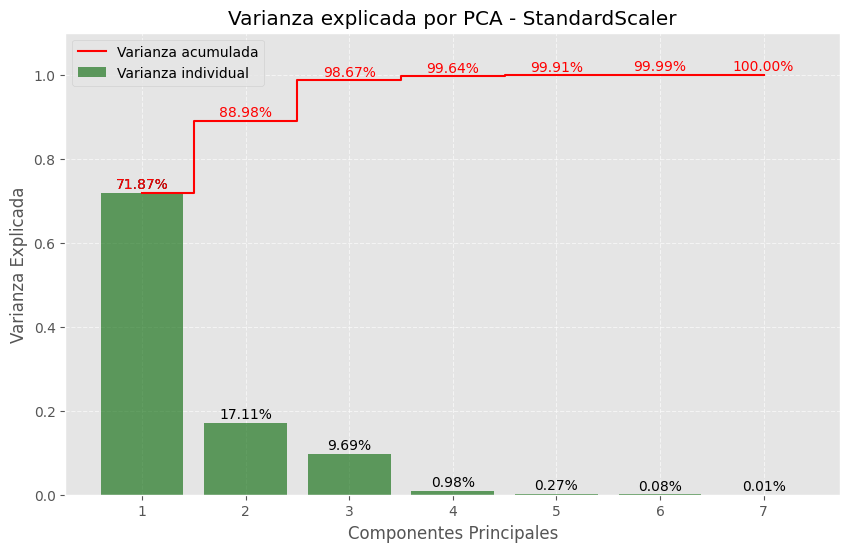

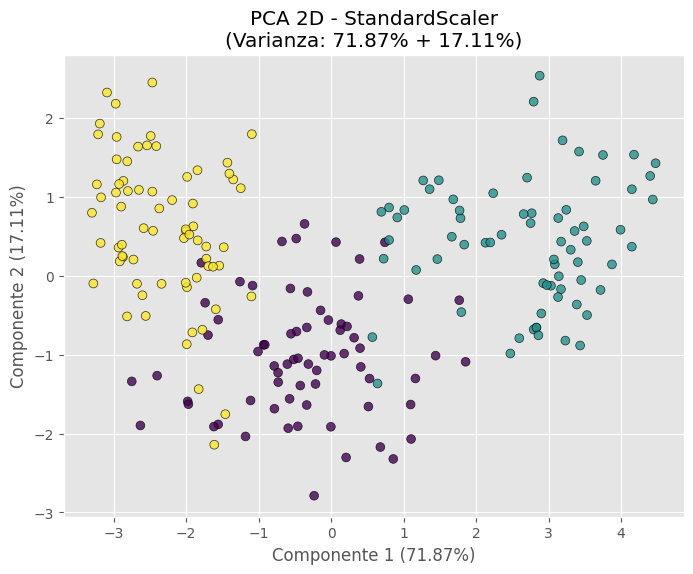

StandardScaler → Varianza acumulada: 71.87% + 17.11% = 88.98%


In [476]:

# StandardScaler
mostrar_varianza(X, StandardScaler(), 'StandardScaler')
mostrar_pca_2d(X, StandardScaler(), 'StandardScaler', seed)


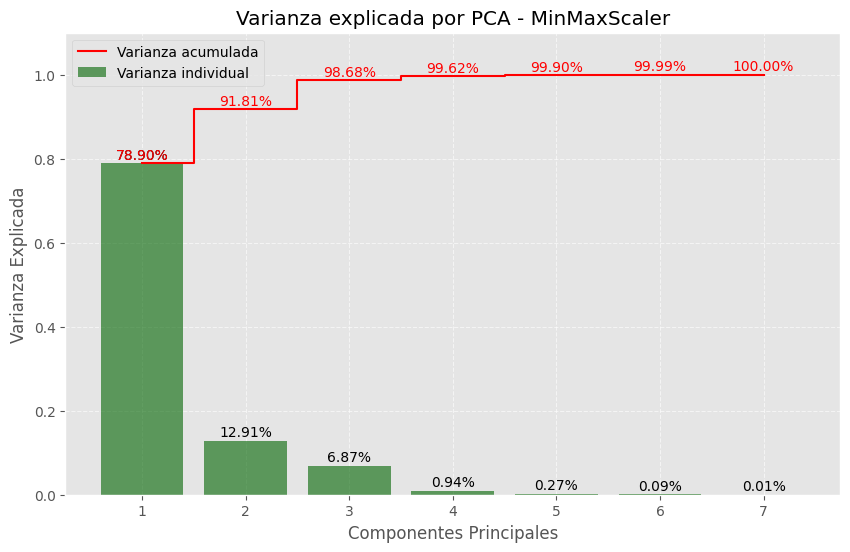

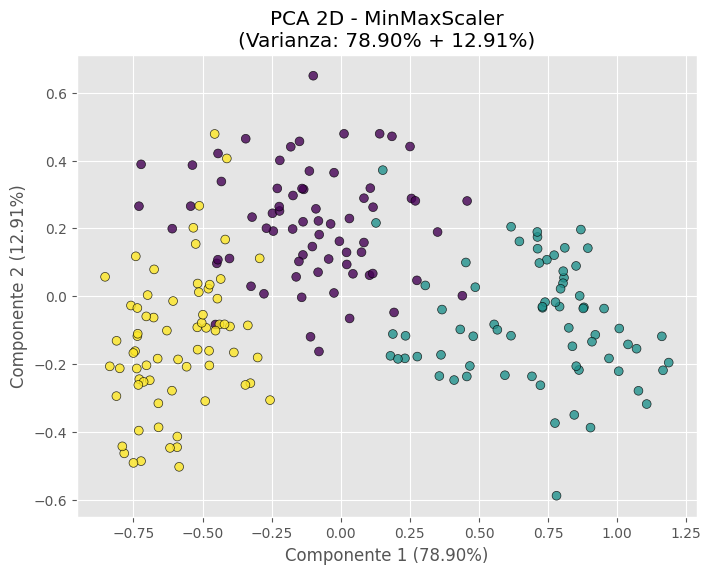

MinMaxScaler → Varianza acumulada: 78.90% + 12.91% = 91.81%


In [477]:
# MinMaxScaler
mostrar_varianza(X, MinMaxScaler(), 'MinMaxScaler')
mostrar_pca_2d(X, MinMaxScaler(), 'MinMaxScaler', seed + 1)

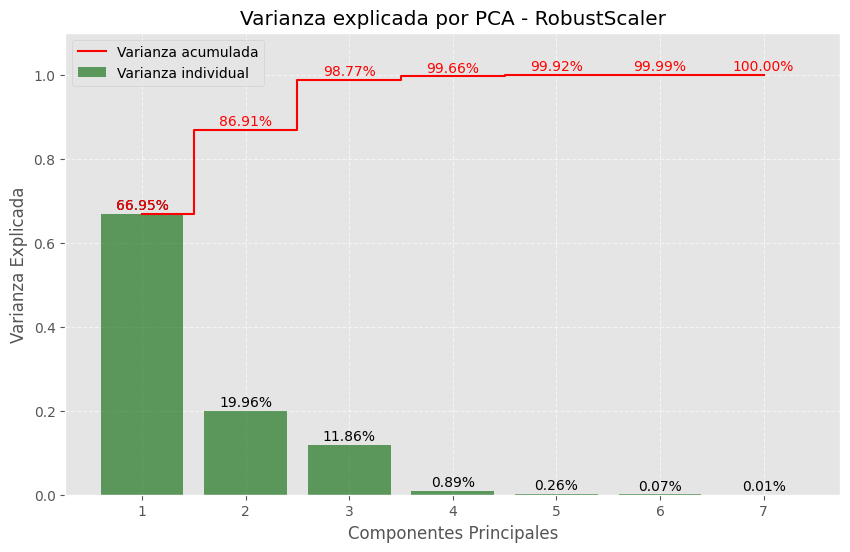

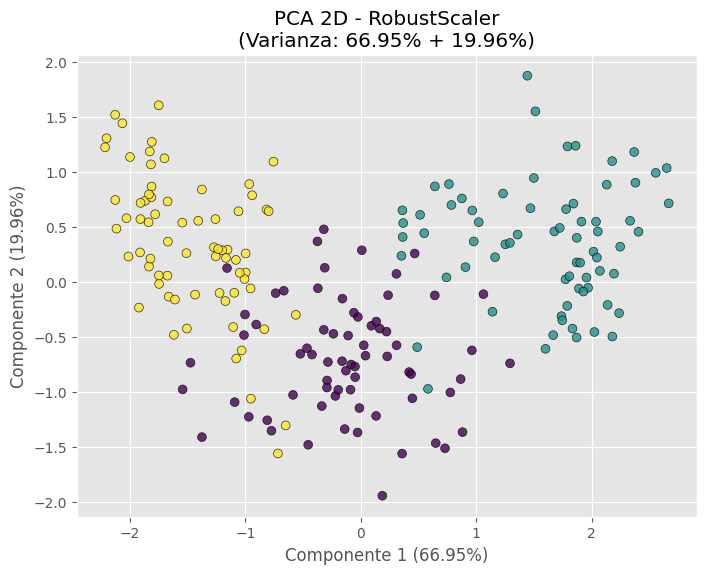

RobustScaler → Varianza acumulada: 66.95% + 19.96% = 86.91%


In [478]:
# RobustScaler
mostrar_varianza(X, RobustScaler(), 'RobustScaler')
mostrar_pca_2d(X, RobustScaler(), 'RobustScaler', seed + 2)

### Conclusión del análisis PCA

Tras comparar los tres escaladores, observamos que `MinMaxScaler` conserva la mayor varianza acumulada en las dos primeras componentes principales. Por tanto, será el escalador seleccionado para continuar con el análisis de clustering.


___
## K-Means Clustering

Aplicamos el algoritmo de K-Means para descubrir agrupamientos naturales en los datos reducidos a dos dimensiones con MinMaxScaler + PCA.  
Este algoritmo intenta particionar los datos en `k` grupos minimizando la varianza intra-cluster.  
Usaremos dos métodos para seleccionar el número óptimo de clusters:
- El **método del codo**, basado en la inercia.
- El **método del índice de silueta**, que evalúa la cohesión y separación entre clusters.


In [479]:
# 📌 Preparar datos reducidos con MinMaxScaler y PCA (2D)
pipeline_minmax_pca = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA(n_components=2))
])

X_reducido = pipeline_minmax_pca.fit_transform(X)


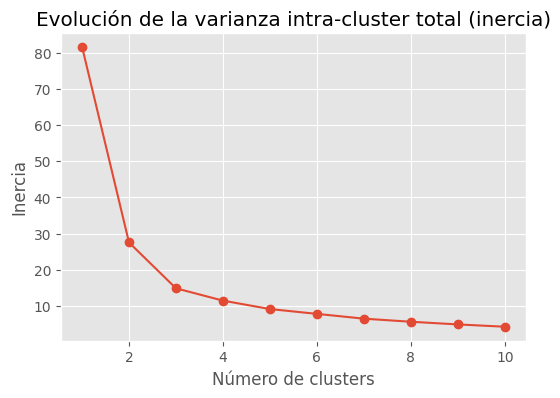

In [480]:
from sklearn.cluster import KMeans

rango_n_clusters = range(1, 11)
inertias = []

for n_clusters in rango_n_clusters:
    modelo_kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
    modelo_kmeans.fit(X_reducido)
    inertias.append(modelo_kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(rango_n_clusters, inertias, marker='o')
plt.title("Evolución de la varianza intra-cluster total (inercia)")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()


### Interpretación del método del codo

En la gráfica se observa cómo la inercia disminuye a medida que aumentamos el número de clusters.  
Buscamos el punto a partir del cual la mejora es marginal: ese "codo" indica un valor óptimo de `k`.  
Según la forma de la curva, los candidatos suelen estar entre `k = 2` y `k = 3`, lo cual será validado con el índice de silueta.


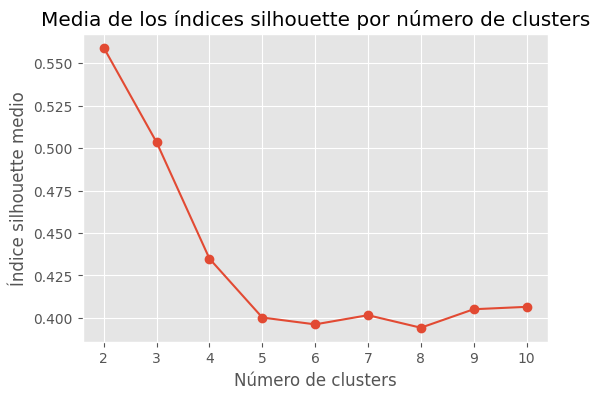

In [481]:
from sklearn.metrics import silhouette_score

rango_n_clusters = range(2, 11)
valores_medios_silhouette = []

for n_clusters in rango_n_clusters:
    modelo_kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
    etiquetas = modelo_kmeans.fit_predict(X_reducido)
    silhouette_avg = silhouette_score(X_reducido, etiquetas)
    valores_medios_silhouette.append(silhouette_avg)

plt.figure(figsize=(6, 4))
plt.plot(rango_n_clusters, valores_medios_silhouette, marker='o')
plt.title("Media de los índices silhouette por número de clusters")
plt.xlabel("Número de clusters")
plt.ylabel("Índice silhouette medio")
plt.grid(True)
plt.show()



### Selección de `k` final

El valor de `k` con el mayor índice de silueta representa la mejor estructura de clusters encontrada.  
En este caso, `k = 2` tiene la puntuación más alta, lo que indica que los datos forman dos agrupaciones bien separadas.

Este será el número de clusters utilizado en la visualización final de K-Means.


### Visualización final de los clusters con K-Means (`k = 2`)

A continuación se representa la agrupación generada por K-Means sobre los datos proyectados con PCA en 2 dimensiones.  
Cada color representa un cluster, y el gráfico permite observar la separación y distribución de los grupos formados por el algoritmo.


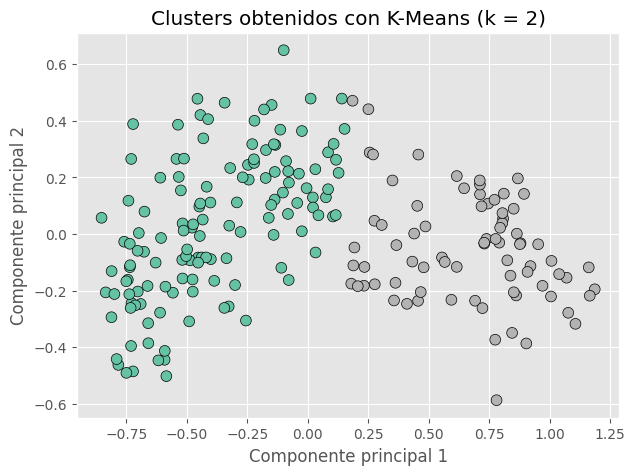

In [482]:
# 📌 Ajustar y predecir con k=2
modelo_kmeans_final = KMeans(n_clusters=2, n_init=20, random_state=42)
labels_kmeans = modelo_kmeans_final.fit_predict(X_reducido)

# 📊 Visualización
plt.figure(figsize=(7, 5))
plt.scatter(
    X_reducido[:, 0], X_reducido[:, 1],
    c=labels_kmeans,
    cmap='Set2',
    s=60,
    edgecolor='k'
)
plt.title("Clusters obtenidos con K-Means (k = 2)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.grid(True)
plt.show()


___
## Clustering Jerárquico (Aglomerativo)

El clustering jerárquico construye una jerarquía de agrupamientos mediante un enfoque de “fusión”, en el que cada punto comienza siendo un cluster individual y se van uniendo sucesivamente según una métrica de distancia.

Exploraremos tres métodos de enlace (`ward`, `complete`, `average`) mediante dendrogramas generados directamente desde el modelo `AgglomerativeClustering`.  
Después seleccionaremos el número óptimo de clusters usando el índice de silueta y visualizaremos el resultado final.


In [483]:
from scipy.cluster.hierarchy import dendrogram

def plot_dendrogram(model, **kwargs):
    """
    Extrae la información de un modelo AgglomerativeClustering
    y representa su dendrograma.
    """
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([
        model.children_,
        model.distances_,
        counts
    ]).astype(float)

    dendrogram(linkage_matrix, **kwargs)


In [484]:
from sklearn.cluster import AgglomerativeClustering

# Crear modelos con los tres métodos de enlace
modelos = {}
for metodo in ['ward', 'complete', 'average']:
    modelo = AgglomerativeClustering(
        linkage=metodo,
        distance_threshold=0,
        n_clusters=None
    )
    modelo.fit(X_reducido)
    modelos[metodo] = modelo



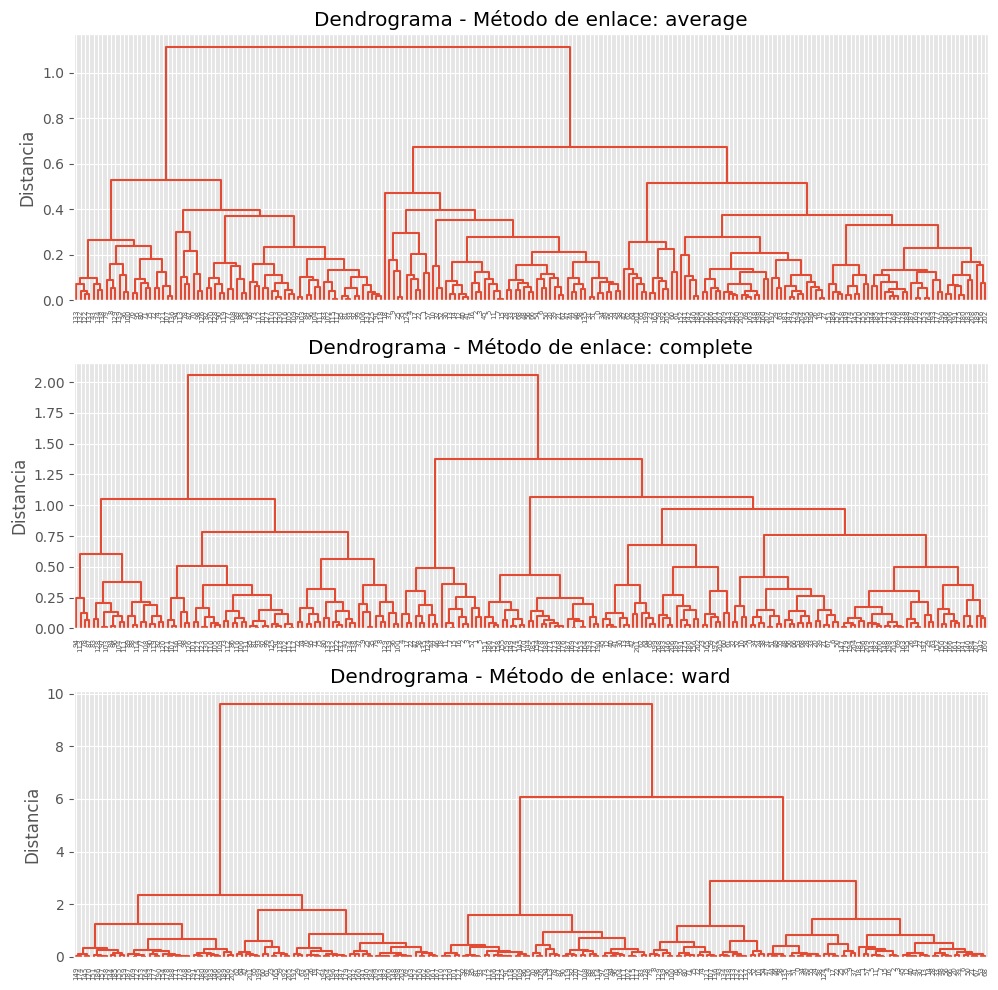

In [485]:
fig, axs = plt.subplots(3, 1, figsize=(10, 10))

for i, metodo in enumerate(['average', 'complete', 'ward']):
    plot_dendrogram(modelos[metodo], ax=axs[i], color_threshold=0)
    axs[i].set_title(f'Dendrograma - Método de enlace: {metodo}')
    axs[i].set_ylabel("Distancia")
    axs[i].grid(True)

plt.tight_layout()
plt.show()


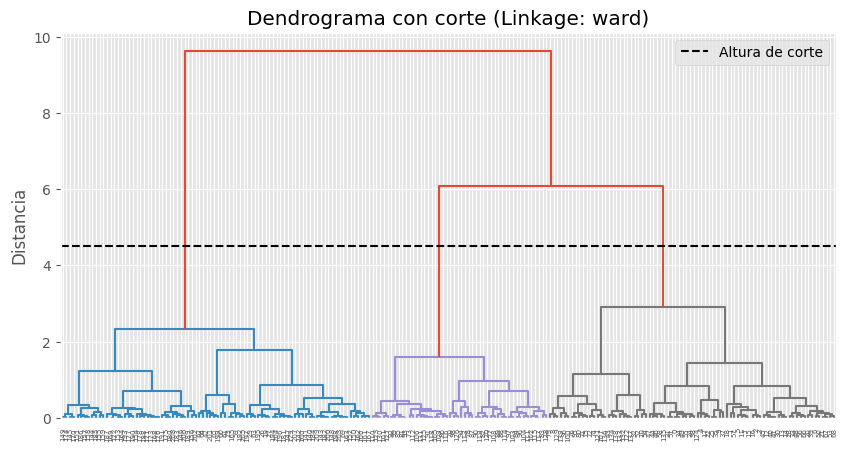

In [486]:
# Definir altura de corte
altura_corte = 4.5

fig, ax = plt.subplots(figsize=(10, 5))
plot_dendrogram(modelos['ward'], ax=ax, color_threshold=altura_corte)
ax.axhline(y=altura_corte, color='black', linestyle='--', label='Altura de corte')
ax.set_title("Dendrograma con corte (Linkage: ward)")
ax.set_ylabel("Distancia")
ax.legend()
plt.show()



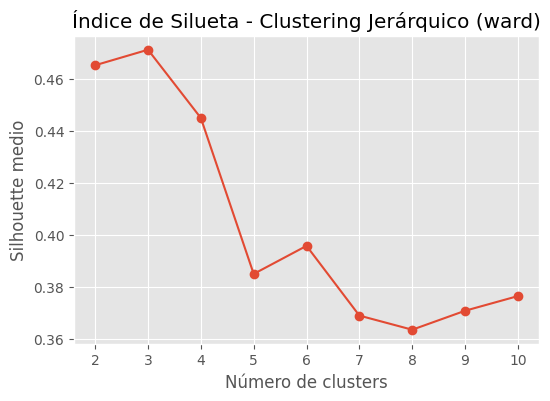

In [487]:
from sklearn.metrics import silhouette_score

range_n = range(2, 11)
silhouettes = []

for k in range_n:
    modelo = AgglomerativeClustering(linkage='ward', n_clusters=k)
    etiquetas = modelo.fit_predict(X_reducido)
    sil_score = silhouette_score(X_reducido, etiquetas)
    silhouettes.append(sil_score)

plt.figure(figsize=(6, 4))
plt.plot(range_n, silhouettes, marker='o')
plt.title("Índice de Silueta - Clustering Jerárquico (ward)")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette medio")
plt.grid(True)
plt.show()



### Selección del número de clusters

El índice de silueta máximo se obtiene con `k = 3` (`silhouette ≈ 0.4714`), lo que indica que es el número de clusters más adecuado para el método jerárquico `ward`.

Este valor es distinto al obtenido con K-Means (`k = 2`), lo que es habitual en aprendizaje no supervisado: cada algoritmo capta estructuras diferentes en los datos.



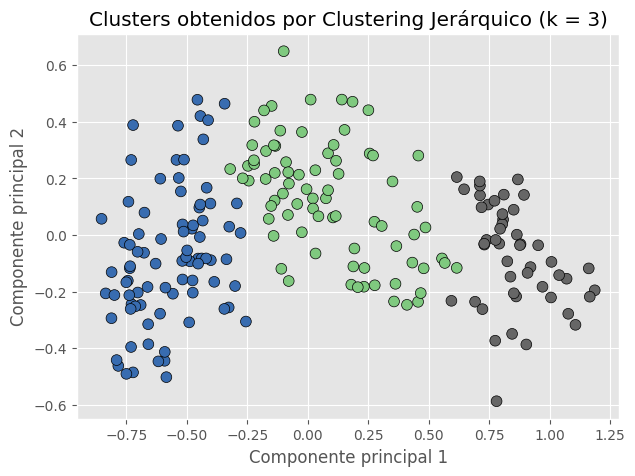

In [488]:
modelo_final_jerarquico = AgglomerativeClustering(linkage='ward', n_clusters=3)
labels_jerarquico = modelo_final_jerarquico.fit_predict(X_reducido)

plt.figure(figsize=(7, 5))
plt.scatter(
    X_reducido[:, 0], X_reducido[:, 1],
    c=labels_jerarquico,
    cmap='Accent',
    s=60,
    edgecolor='k'
)
plt.title("Clusters obtenidos por Clustering Jerárquico (k = 3)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.grid(True)
plt.show()


___
## Clustering basado en densidad – DBSCAN

DBSCAN es un algoritmo que encuentra agrupamientos basándose en densidades locales de puntos.  
A diferencia de K-Means y Jerárquico, no requiere especificar el número de clusters y puede identificar puntos **ruidosos (outliers)** que no pertenecen a ningún grupo.

Los hiperparámetros clave son:
- `eps`: radio máximo para considerar que dos puntos son vecinos
- `min_samples`: número mínimo de vecinos dentro de `eps` para formar un cluster


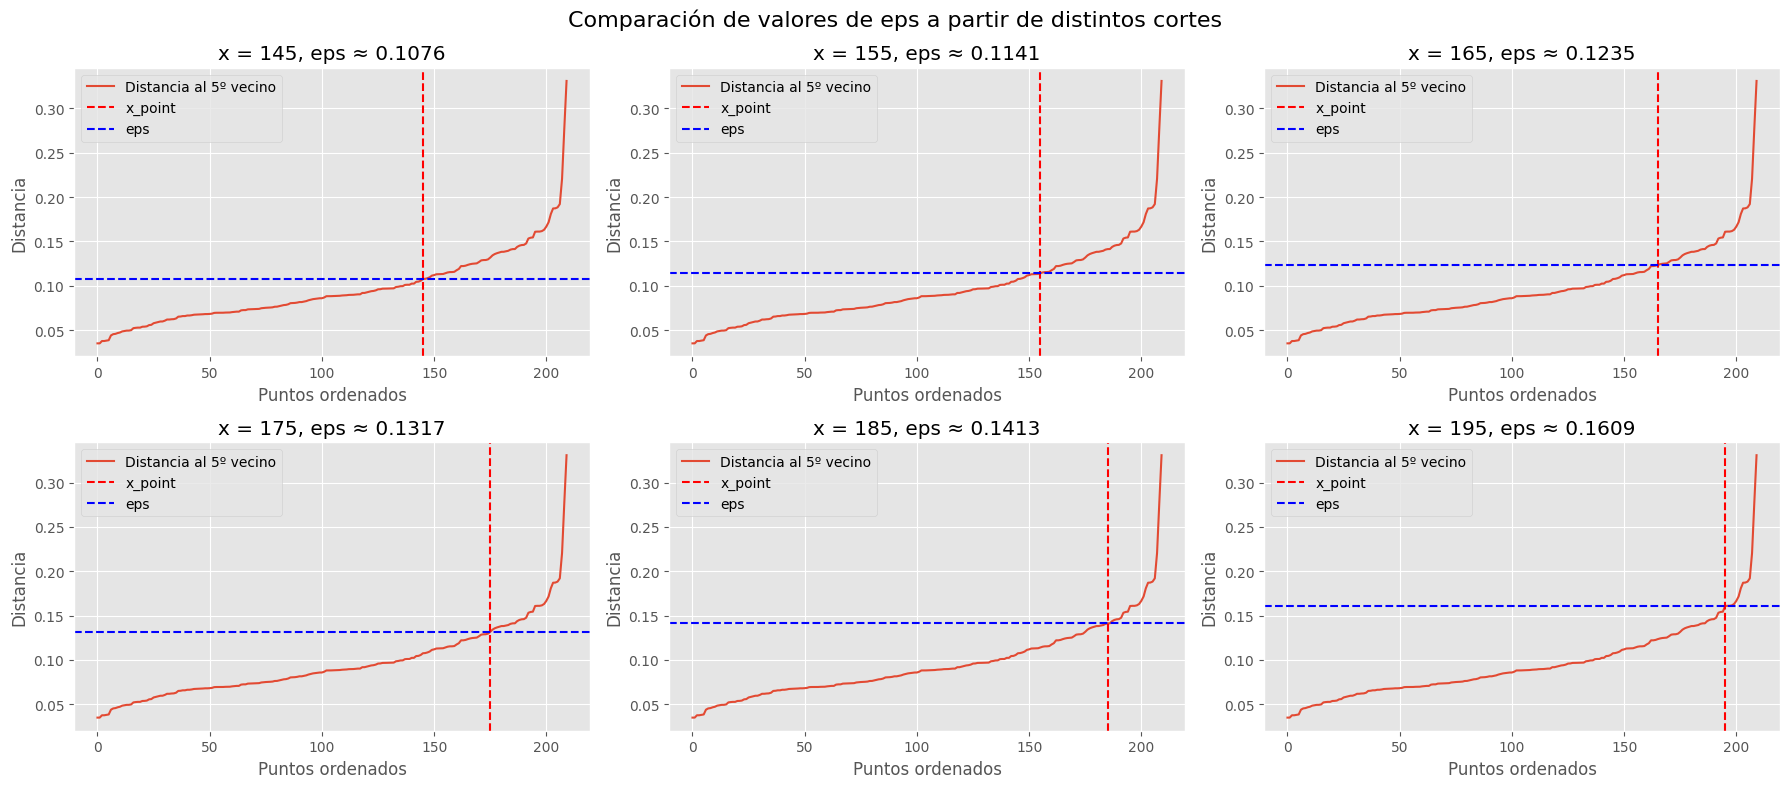

In [489]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

min_samples = 5
x_points = list(range(145, 196, 10))

# Calcular distancias
nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_reducido)
distancias, _ = nn.kneighbors(X_reducido)
distancias_ordenadas = np.sort(distancias[:, min_samples - 1])

# Crear subplots
fig, axs = plt.subplots(2, 3, figsize=(18, 8))
axs = axs.ravel()

for i, x_point in enumerate(x_points):
    y_eps = distancias_ordenadas[x_point]

    axs[i].plot(distancias_ordenadas, label='Distancia al 5º vecino')
    axs[i].axvline(x=x_point, color='red', linestyle='--', label='x_point')
    axs[i].axhline(y=y_eps, color='blue', linestyle='--', label='eps')
    axs[i].set_title(f"x = {x_point}, eps ≈ {y_eps:.4f}")
    axs[i].set_xlabel("Puntos ordenados")
    axs[i].set_ylabel("Distancia")
    axs[i].legend()
    axs[i].grid(True)

plt.suptitle("Comparación de valores de eps a partir de distintos cortes", fontsize=16)
plt.tight_layout()
plt.show()


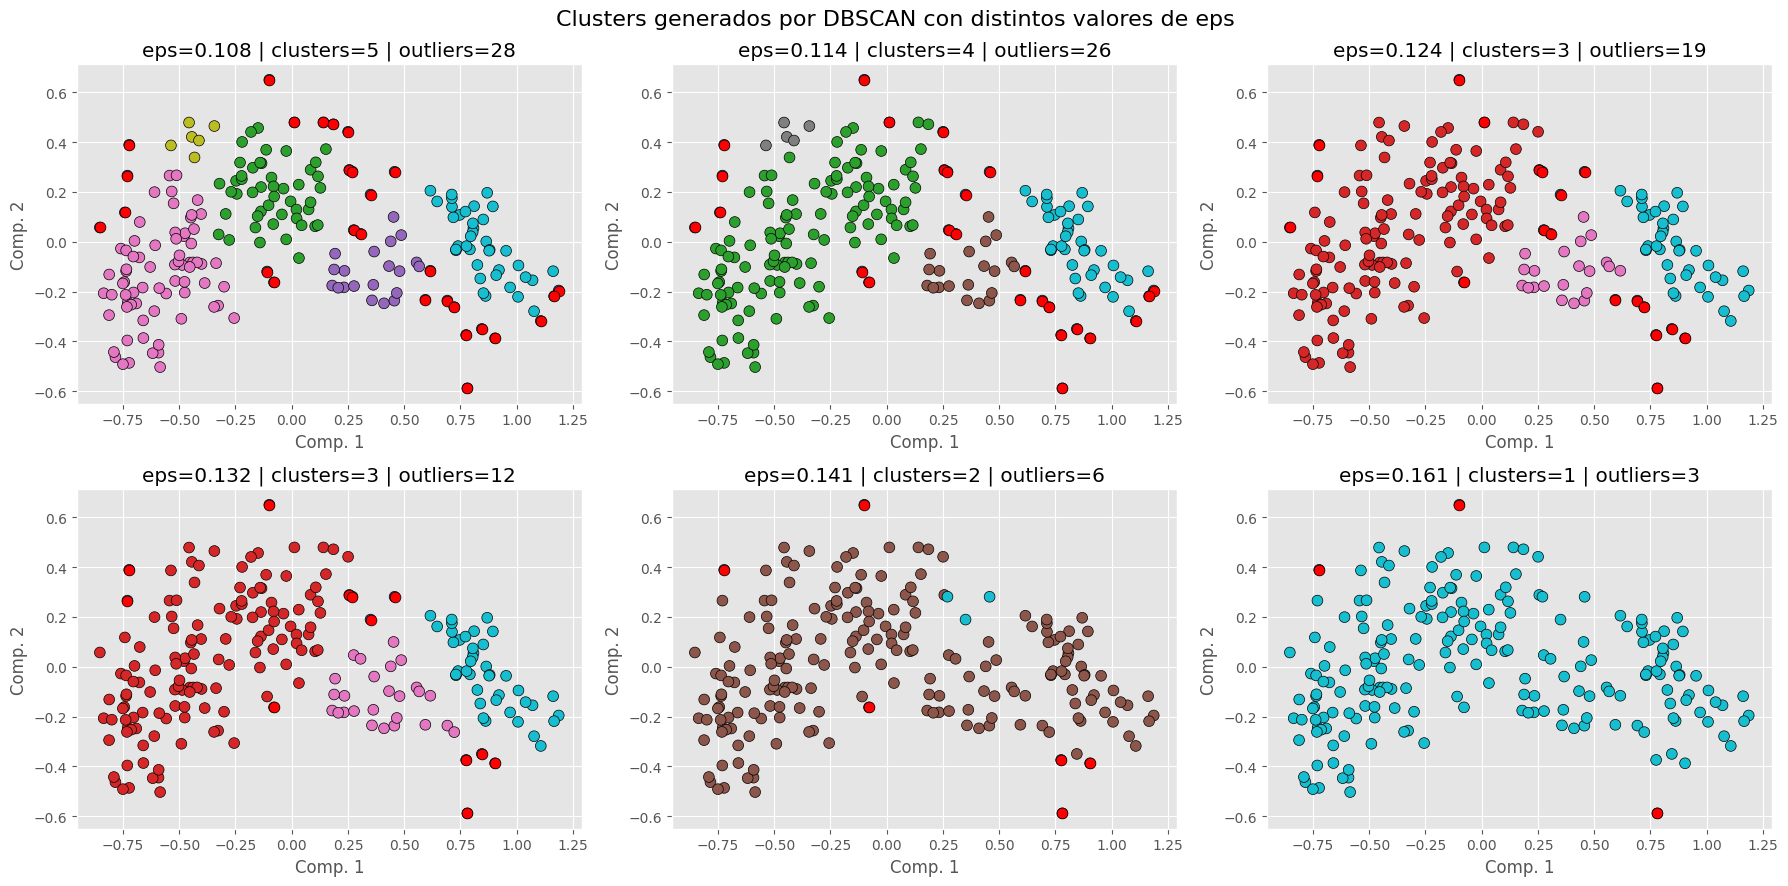

In [490]:
from sklearn.cluster import DBSCAN

fig, axs = plt.subplots(2, 3, figsize=(18, 9))
axs = axs.ravel()

for i, x_point in enumerate(x_points):
    eps = distancias_ordenadas[x_point]
    modelo_dbscan = DBSCAN(eps=eps, min_samples=5, metric='euclidean')
    labels = modelo_dbscan.fit_predict(X_reducido)

    # Pintar puntos del cluster
    axs[i].scatter(
        X_reducido[:, 0], X_reducido[:, 1],
        c=labels,
        cmap='tab10',
        s=60,
        edgecolor='k'
    )

    # Pintar outliers
    axs[i].scatter(
        X_reducido[labels == -1, 0],
        X_reducido[labels == -1, 1],
        c='red',
        s=60,
        edgecolor='k',
        label='Outliers'
    )

    # Métricas
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_outliers = list(labels).count(-1)

    axs[i].set_title(f"eps={eps:.3f} | clusters={n_clusters} | outliers={n_outliers}")
    axs[i].set_xlabel("Comp. 1")
    axs[i].set_ylabel("Comp. 2")
    axs[i].grid(True)

plt.suptitle("Clusters generados por DBSCAN con distintos valores de eps", fontsize=16)
plt.tight_layout()
plt.show()


In [491]:
# Volver a entrenar el modelo final con el mejor eps elegido (0.132)
eps_final = 0.132
modelo_dbscan = DBSCAN(eps=eps_final, min_samples=5)
labels_dbscan = modelo_dbscan.fit_predict(X_reducido)

# Puedes opcionalmente imprimir los datos
n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_outliers = list(labels_dbscan).count(-1)
print(f"[Modelo final] Clusters = {n_clusters}, Outliers = {n_outliers}")


[Modelo final] Clusters = 3, Outliers = 12


### Conclusión del clustering con DBSCAN

DBSCAN ha demostrado ser una técnica eficaz para identificar agrupamientos sin necesidad de fijar el número de clusters previamente.  
Además, ha permitido detectar puntos considerados como **ruido** (etiquetados como `-1`), lo que resulta útil en presencia de datos atípicos o dispersos.

Para ajustar el parámetro `eps`, se ha generado un gráfico `k-distance` y se han probado distintos valores de corte (`x_point` de 145 a 195).  
A partir de estos, se entrenaron múltiples modelos de DBSCAN con los valores correspondientes de `eps`, comparando visualmente los resultados obtenidos.

Los modelos han producido resultados variados:

- Con `eps` más pequeños (e.g. **0.114**), se detectan más clusters pero también muchos outliers (hasta **26**).
- Con `eps` más grandes (e.g. **0.188**), se reduce el número de outliers, pero se pierde la estructura del agrupamiento y todos los puntos caen en un único cluster.
- El valor **`eps ≈ 0.132`** (correspondiente a `x_point = 175`) ha ofrecido un **equilibrio óptimo**, identificando **3 clusters** con una cantidad razonable de outliers (**12**), capturando bien la estructura general del conjunto de datos.

Por tanto, se ha seleccionado `eps = 0.132` como valor final para aplicar DBSCAN, con `min_samples = 5`.  
Este ajuste proporciona una segmentación interpretable, sin forzar la asignación de todos los puntos a un grupo y respetando la variabilidad natural del conjunto de datos.

DBSCAN se confirma como una herramienta especialmente útil cuando:

- No se conoce el número de clusters con antelación.
- Se espera ruido o puntos atípicos.
- La forma de los grupos no es necesariamente esférica.


___
## Comparación final de resultados y conclusiones

En esta última sección comparamos los resultados obtenidos por los tres algoritmos de clustering aplicados a los datos:  
- **K-Means**  
- **Clustering Jerárquico (linkage ward)**  
- **DBSCAN**

El objetivo es analizar cuál de ellos proporciona una agrupación más coherente, interpretable y útil según diferentes criterios:

- Visualización de clusters proyectados en 2D (PCA)
- Número de clusters y outliers detectados
- Correspondencia co


### Visualización de agrupamientos

A continuación representamos los resultados de cada algoritmo proyectados en las dos primeras componentes principales (PCA).  
Esto nos permite comparar visualmente cómo agrupa los datos cada uno y si la estructura visual se corresponde con una separación razonable.
    

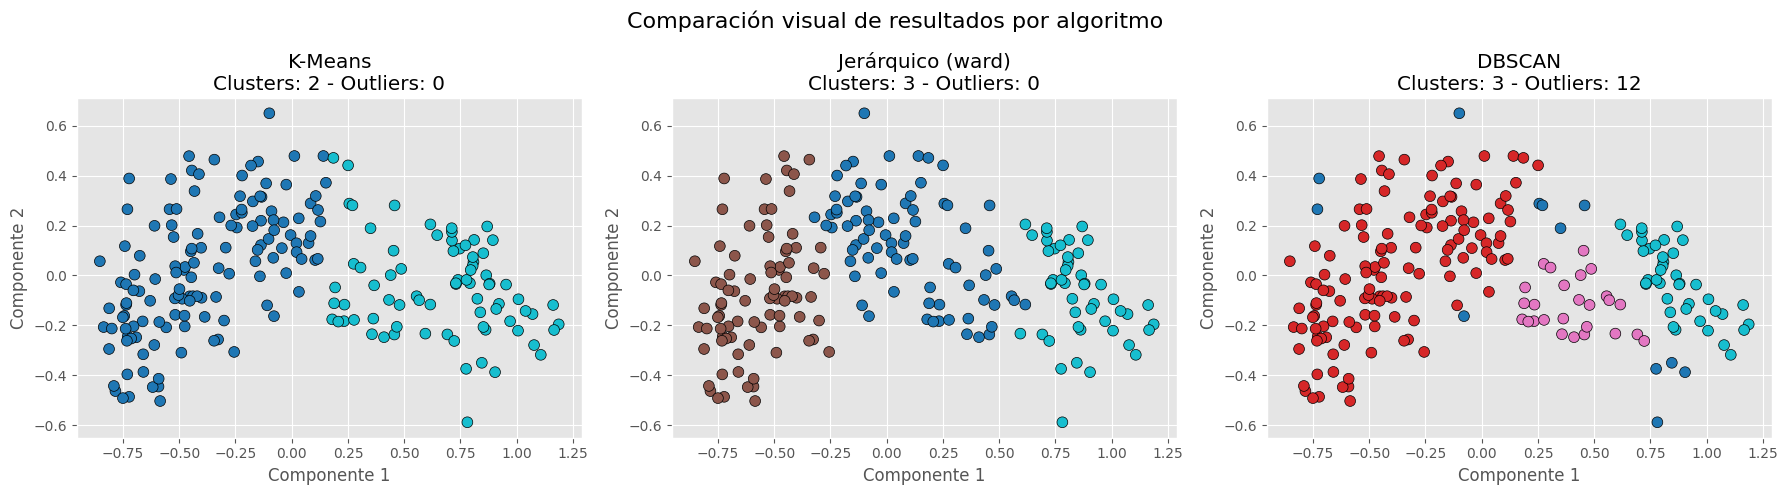

In [492]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

algoritmos = [
    ("K-Means", labels_kmeans),
    ("Jerárquico (ward)", labels_jerarquico),
    ("DBSCAN", labels_dbscan)
]

for i, (nombre, labels) in enumerate(algoritmos):
    axs[i].scatter(
        X_reducido[:, 0], X_reducido[:, 1],
        c=labels,
        cmap='tab10',
        s=60,
        edgecolor='k'
    )
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_outliers = list(labels).count(-1) if -1 in labels else 0

    axs[i].set_title(f"{nombre}\nClusters: {n_clusters} - Outliers: {n_outliers}")
    axs[i].set_xlabel("Componente 1")
    axs[i].set_ylabel("Componente 2")
    axs[i].grid(True)

plt.suptitle("Comparación visual de resultados por algoritmo", fontsize=16)
plt.tight_layout()
plt.show()


### Correspondencia con las clases reales

Aunque el clustering es una técnica no supervisada, podemos comparar los clusters obtenidos con la variable real "clase" (que no ha sido usada para entrenar)  
para ver hasta qué punto cada algoritmo es capaz de reproducir la segmentación verdadera.

Lo hacemos con tablas cruzadas que comparan cada cluster con la clase real.


In [493]:
# Añadir etiquetas al DataFrame
df['kmeans'] = labels_kmeans
df['jerarquico'] = labels_jerarquico
df['dbscan'] = labels_dbscan

# Tablas cruzadas
print("K-Means vs Clase real:")
print(pd.crosstab(df['clase'], df['kmeans']), end="\n\n")

print("Jerárquico vs Clase real:")
print(pd.crosstab(df['clase'], df['jerarquico']), end="\n\n")

print("DBSCAN vs Clase real:")
print(pd.crosstab(df['clase'], df['dbscan']))


K-Means vs Clase real:
kmeans   0   1
clase         
1       61   9
2        2  68
3       70   0

Jerárquico vs Clase real:
jerarquico   0   1   2
clase                 
1           56  14   0
2           22   0  48
3            0  70   0

DBSCAN vs Clase real:
dbscan  -1   0   1   2
clase                 
1        8  59   3   0
2        4   2  23  41
3        0  70   0   0


### Interpretación de atributos por cluster

Para entender qué define a cada grupo, representamos boxplots por atributo para cada método.  
Esto nos permite observar cómo varían las variables originales dentro de cada cluster y facilita la interpretación práctica de los resultados.


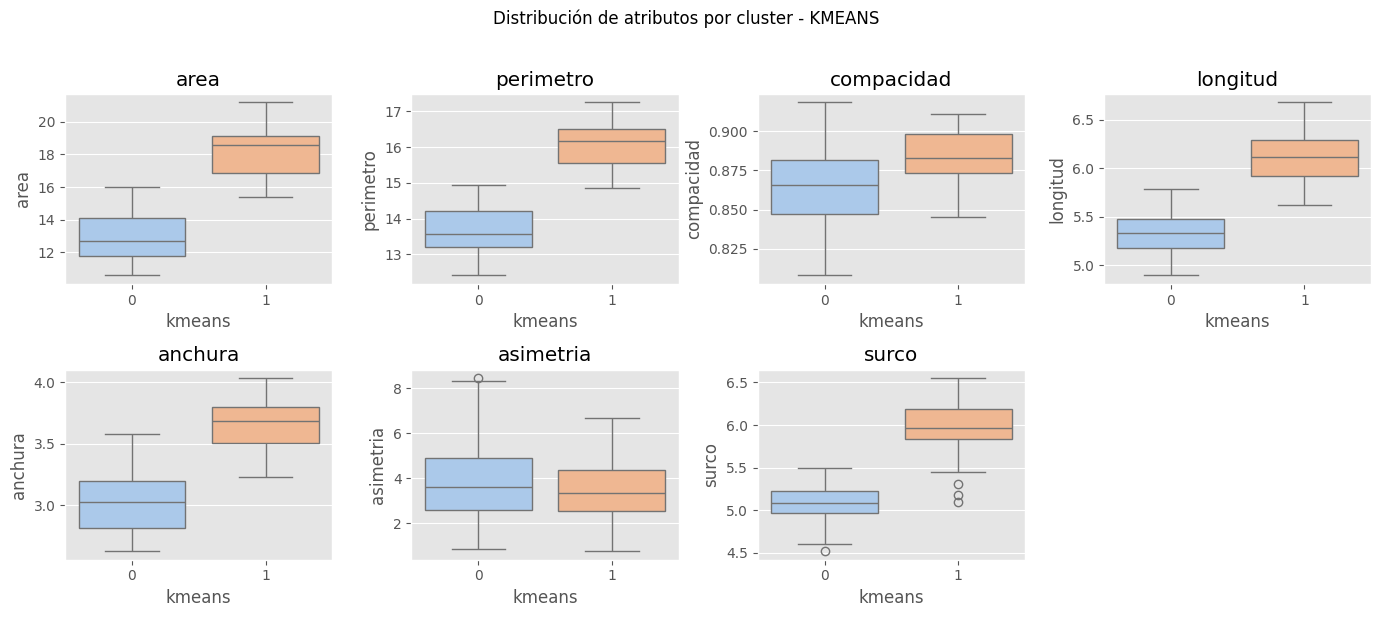

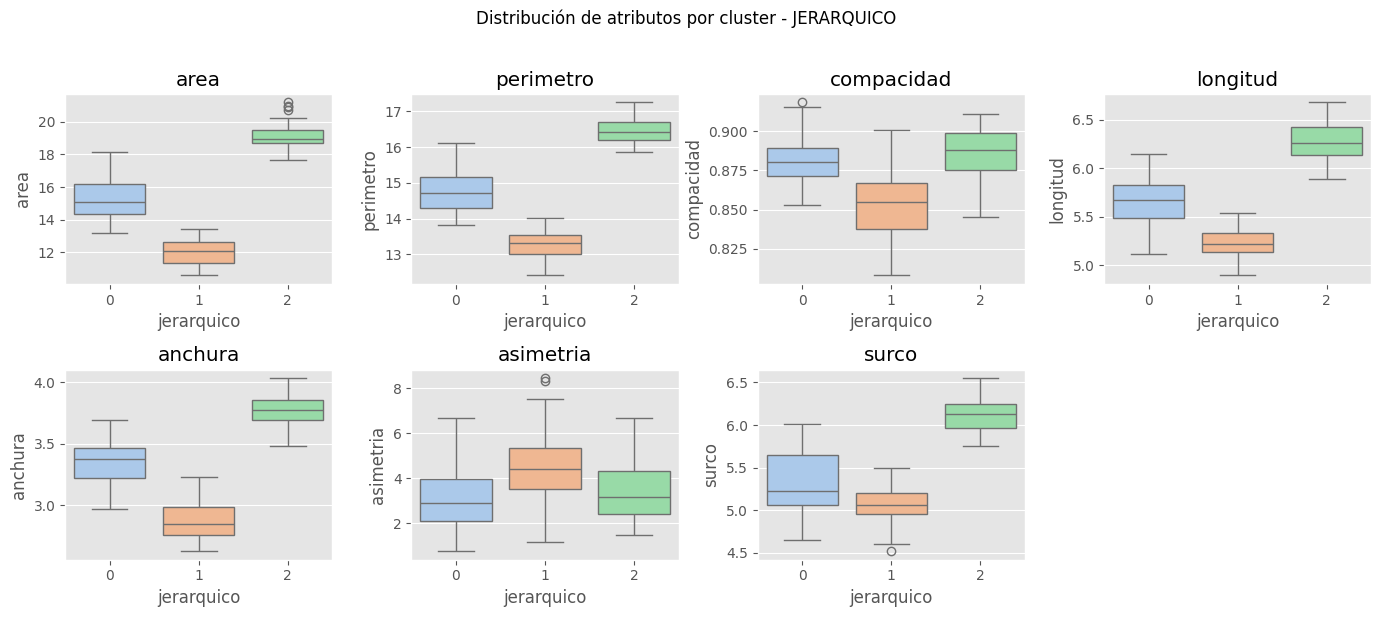

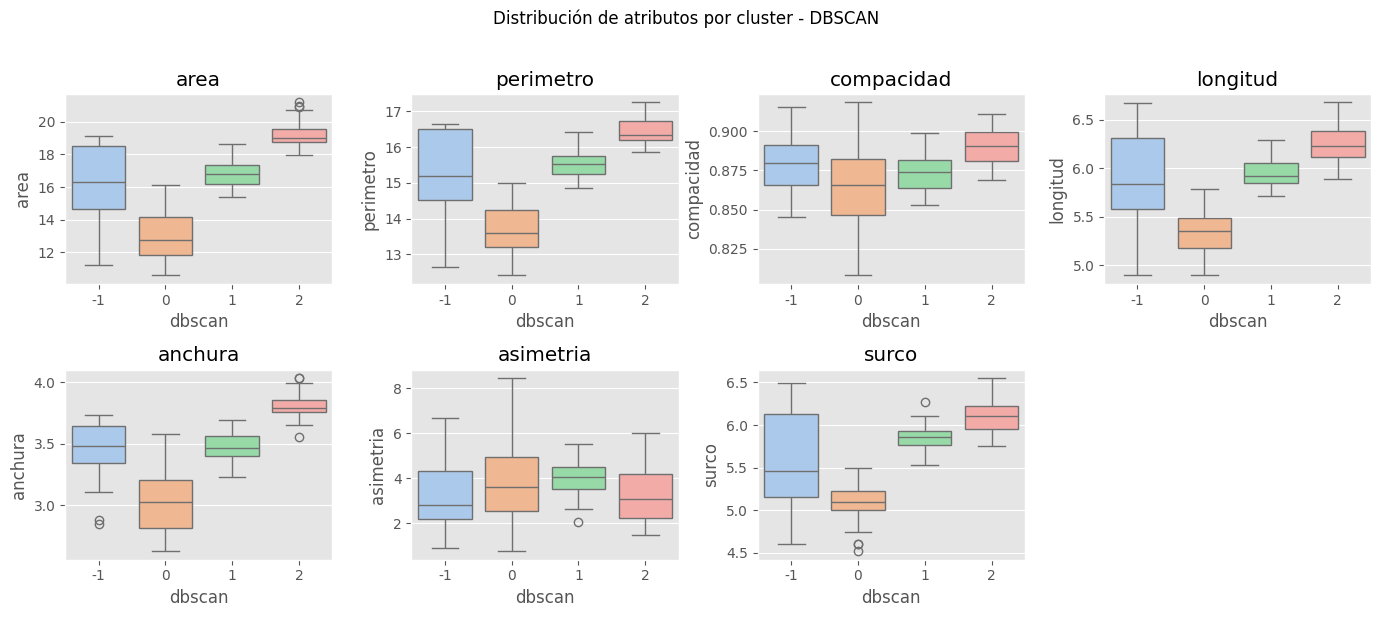

In [494]:
import seaborn as sns

atributos = df.columns[:-4]  # Excluye clase y columnas de clustering

for metodo in ["kmeans", "jerarquico", "dbscan"]:
    plt.figure(figsize=(14, 6))
    for i, atributo in enumerate(atributos):
        plt.subplot(2, 4, i+1)
        sns.boxplot(data=df, x=metodo, y=atributo, hue=metodo, palette='pastel', legend=False)
        plt.title(atributo)
    plt.suptitle(f"Distribución de atributos por cluster - {metodo.upper()}", y=1.02)
    plt.tight_layout()
    plt.show()


## Conclusión final del análisis

Tras aplicar los tres algoritmos de clustering, se pueden extraer las siguientes conclusiones:

---

### K-Means
- Se seleccionó `k = 2` como valor óptimo usando el método del codo y el coeficiente de silueta.
- Funciona bien si los grupos son esféricos y tienen tamaño similar.
- La visualización muestra una separación clara pero un poco forzada.
- **No detecta outliers**, todos los puntos quedan asignados a algún cluster.
- La tabla cruzada muestra una separación parcial: algunas clases están mezcladas.

---

### Clustering Jerárquico (ward)
- El coeficiente de silueta máximo se obtuvo con `k = 3`.
- La segmentación visual es más natural y respeta mejor la estructura real.
- Permite estudiar distintos niveles de agrupación a través del dendrograma.
- La tabla cruzada muestra una clara correspondencia con las clases.
- **Es el algoritmo más interpretativo y coherente en este problema.**

---

### DBSCAN
- Se probaron distintos valores de `eps` mediante el gráfico de distancias al 5.º vecino.
- El valor elegido (`eps = 0.132`) dio 3 clusters y 12 outliers.
- Detecta agrupaciones con formas arbitrarias y puntos ruidosos.
- Algunos puntos útiles pueden quedar etiquetados como ruido si el parámetro no está bien ajustado.
- La visualización es clara, pero puede depender mucho de `eps`.

---

## Conclusión general

- **Jerárquico (ward)** es el que mejor ha reproducido la estructura natural de los datos y ha ofrecido una agrupación clara, bien segmentada y coherente con las clases reales.
- **DBSCAN** ha sido útil para detectar ruido y formas no esféricas, pero puede ser más sensible a los parámetros.
- **K-Means** es rápido y razonable, pero tiende a forzar la estructura de los datos.

Por tanto, **nos quedamos con Clustering Jerárquico como la mejor solución para este problema**, ya que proporciona los clusters más interpretables, con mejor separación y más alineados con las clases reales.
